<a href="https://colab.research.google.com/github/Shoukat-Ali123/Machine-Learning-01/blob/main/crypto_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean Absolute Error (MAE): 184.92
Mean Squared Error (MSE): 565256.68
Root Mean Squared Error (RMSE): 751.84
R² Score: 0.09
Model Accuracy: 0.94%


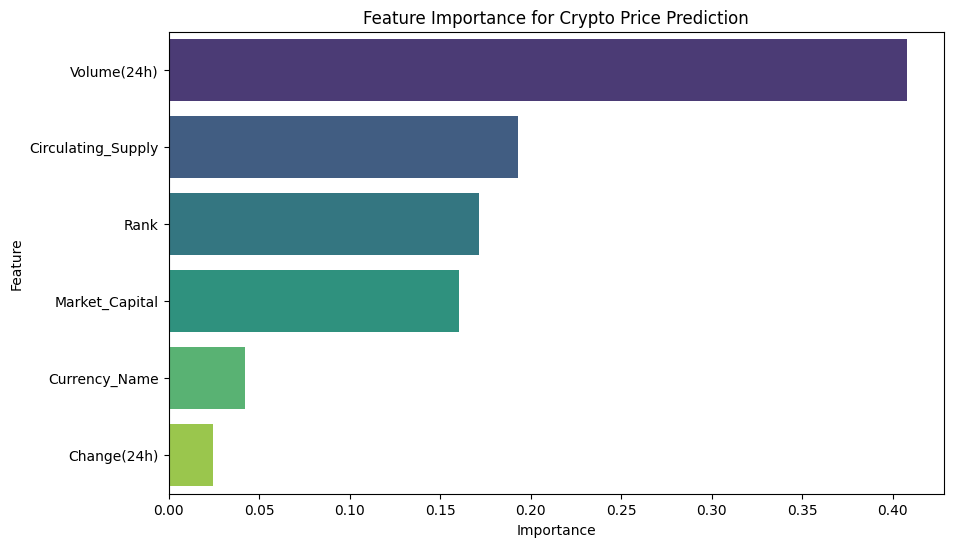

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Data.csv')

# Clean numeric columns
df['Market_Capital'] = df['Market_Capital'].replace({'\$':'', ',':''}, regex=True).astype(float)
df['Price'] = df['Price'].replace({'\$':'', ',':''}, regex=True).astype(float)
df['Circulating_Supply'] = df['Circulating_Supply'].replace({',':''}, regex=True).astype(float)
df['Volume(24h)'] = df['Volume(24h)'].replace({'\$':'', ',':''}, regex=True).astype(float)
df['Change(24h)'] = df['Change(24h)'].replace({'%':''}, regex=True).astype(float)

# Encode categorical column
le = LabelEncoder()
df['Currency_Name'] = le.fit_transform(df['Currency_Name'])

# Features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy_percent = r2*10  # pseudo-accuracy for regression

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Model Accuracy: {accuracy_percent:.2f}%")

# Feature importance
importances = model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Feature Importance for Crypto Price Prediction")
plt.show()